<a href="https://colab.research.google.com/github/njwbilll/Tugas-4_Practical-Statistics-for-Data-Scientists-O-Reilly_Najwa-Bilqis-Al-Khalidah/blob/main/05_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5: Classification

**Referensi:** Practical Statistics for Data Scientists (Peter Bruce, Andrew Bruce, Peter Gedeck)

***

## Ringkasan Chapter

Jika regresi digunakan untuk memprediksi nilai numerik yang kontinu, klasifikasi adalah sekumpulan metode statistik dan mesin pembelajaran yang dirancang untuk memprediksi kategori atau kelas dari sebuah observasi. Tujuannya adalah mengklasifikasikan data ke dalam kelompok yang sudah ditentukan sebelumnya berdasarkan fitur yang dimiliki.

Bab ini membedah algoritma klasifikasi dasar yang sering digunakan oleh para ilmuwan data. Kita akan mengeksplorasi algoritma probabilistik, algoritma pemisah linear, cara mengevaluasi keandalan prediksi, dan bagaimana menangani masalah dataset yang memiliki ketimpangan kelas.

### Topik yang Dibahas:
1. Naive Bayes
2. Analisis Diskriminan (Discriminant Analysis)
3. Regresi Logistik (Logistic Regression)
4. Mengevaluasi Model Klasifikasi
5. Kurva ROC dan Area Under Curve (AUC)
6. Strategi Menangani Data Tidak Seimbang (Imbalanced Data)


***
## Setup: Import Library

Kita menginisialisasi lingkungan kerja dengan memanggil modul manipulasi data numerik, pustaka visualisasi, dan modul algoritma klasifikasi beserta metrik evaluasinya dari scikit-learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

print("Seluruh pustaka klasifikasi berhasil dimuat.")


Seluruh pustaka klasifikasi berhasil dimuat.


***
## 1. Naive Bayes

### Penjelasan Teori

Naive Bayes adalah algoritma klasifikasi probabilistik yang berakar pada Teorema Bayes. Kata naif merujuk pada asumsi penyederhanaan yang sangat berani yaitu semua variabel prediktor dianggap independen atau tidak memiliki korelasi satu sama lain dalam kelas yang sama.

Meskipun asumsi ini jarang terjadi secara sempurna di dunia nyata, algoritma ini terbukti sangat cepat dan efektif, terutama untuk data dengan dimensi tinggi seperti klasifikasi teks. Dalam simulasi ini, kita akan menggunakan Gaussian Naive Bayes yang mengasumsikan distribusi data numerik mengikuti kurva lonceng normal.

Akurasi model Naive Bayes: 98.40 persen


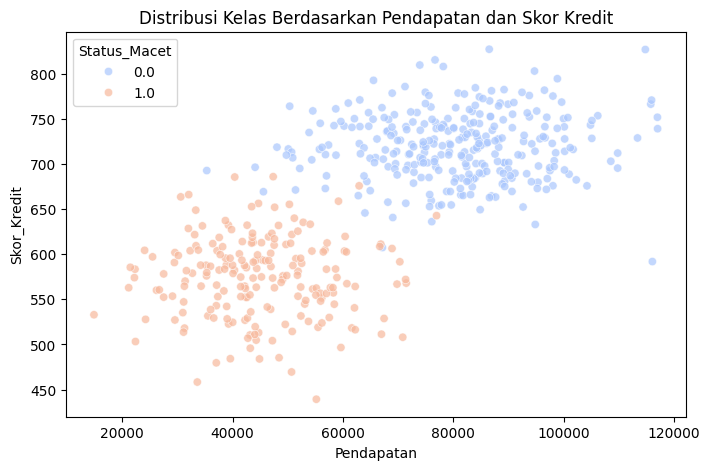

In [2]:
# Simulasi data risiko pinjaman bank
np.random.seed(10)

# Kelas 0 adalah nasabah lancar, Kelas 1 adalah nasabah macet
n_samples = 500
pendapatan_lancar = np.random.normal(loc=80000, scale=15000, size=300)
skor_kredit_lancar = np.random.normal(loc=720, scale=40, size=300)

pendapatan_macet = np.random.normal(loc=45000, scale=12000, size=200)
skor_kredit_macet = np.random.normal(loc=580, scale=50, size=200)

df_nb = pd.DataFrame({
    'Pendapatan': np.concatenate([pendapatan_lancar, pendapatan_macet]),
    'Skor_Kredit': np.concatenate([skor_kredit_lancar, skor_kredit_macet]),
    'Status_Macet': np.concatenate([np.zeros(300), np.ones(200)])
})

X_nb = df_nb[['Pendapatan', 'Skor_Kredit']]
y_nb = df_nb['Status_Macet']

model_nb = GaussianNB()
model_nb.fit(X_nb, y_nb)

prediksi_nb = model_nb.predict(X_nb)
akurasi_nb = accuracy_score(y_nb, prediksi_nb)

print(f"Akurasi model Naive Bayes: {akurasi_nb * 100:.2f} persen")

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Pendapatan', y='Skor_Kredit', hue='Status_Macet', data=df_nb, palette='coolwarm', alpha=0.7)
plt.title('Distribusi Kelas Berdasarkan Pendapatan dan Skor Kredit')
plt.show()


***
## 2. Analisis Diskriminan (Discriminant Analysis)

### Penjelasan Teori

Analisis Diskriminan Linear merupakan salah satu teknik tertua dalam klasifikasi yang diperkenalkan oleh R.A. Fisher. Tujuan utamanya adalah mencari kombinasi linear dari variabel prediktor yang paling optimal dalam memisahkan kelas observasi.

LDA bekerja dengan dua sasaran matematis secara simultan yaitu memaksimalkan jarak antara rata-rata kelompok yang berbeda, dan secara bersamaan meminimalkan varians atau penyebaran data di dalam kelompok yang sama. Metode ini sangat stabil digunakan pada populasi yang terdistribusi normal.

In [3]:
# Menggunakan dataset yang sama dengan Naive Bayes untuk perbandingan
model_lda = LinearDiscriminantAnalysis()
model_lda.fit(X_nb, y_nb)

prediksi_lda = model_lda.predict(X_nb)
akurasi_lda = accuracy_score(y_nb, prediksi_lda)

print(f"Akurasi model Analisis Diskriminan Linear: {akurasi_lda * 100:.2f} persen")

# Mendapatkan koefisien pemisah
koefisien_pendapatan = model_lda.coef_[0][0]
koefisien_skor = model_lda.coef_[0][1]

print(f"Bobot Pendapatan: {koefisien_pendapatan:.5f}")
print(f"Bobot Skor Kredit: {koefisien_skor:.5f}")


Akurasi model Analisis Diskriminan Linear: 98.60 persen
Bobot Pendapatan: -0.00019
Bobot Skor Kredit: -0.08655


***
## 3. Regresi Logistik (Logistic Regression)

### Penjelasan Teori

Walaupun memiliki nama regresi, teknik ini adalah algoritma klasifikasi sejati. Regresi logistik menyelesaikan masalah yang tidak bisa ditangani oleh regresi linear biasa. Regresi linear bisa memprediksi nilai di bawah nol atau di atas satu, yang mana tidak masuk akal untuk probabilitas klasifikasi.

Solusinya adalah membungkus persamaan linear di dalam sebuah fungsi logit atau sigmoid. Fungsi transformasi ini memastikan bahwa output dari model akan selalu melengkung seperti huruf S dan terkurung di antara rentang absolut nol dan satu.

In [4]:
# Kita melakukan pembagian data latih dan uji agar evaluasi lebih realistis
X_train, X_test, y_train, y_test = train_test_split(X_nb, y_nb, test_size=0.3, random_state=42)

model_logreg = LogisticRegression()
model_logreg.fit(X_train, y_train)

prediksi_logreg = model_logreg.predict(X_test)
probabilitas_logreg = model_logreg.predict_proba(X_test)[:, 1]

print("Lima probabilitas prediksi pertama (Peluang menjadi kelas 1):")
print(np.round(probabilitas_logreg[:5], 3))


Lima probabilitas prediksi pertama (Peluang menjadi kelas 1):
[1.    0.051 1.    0.    0.054]


***
## 4. Mengevaluasi Model Klasifikasi

### Penjelasan Teori

Akurasi total hanyalah sebagian kecil dari cerita performa model. Jika prediksi penyakit menular memiliki ketepatan sembilan puluh persen, itu terdengar hebat. Namun jika ternyata sepuluh persen sisanya adalah orang yang benar sakit lalu dinyatakan sehat (False Negative), dampaknya akan sangat fatal.

Matriks Konfusi (Confusion Matrix) memberikan rincian lengkap dari prediksi model ke dalam empat kuadran:
* True Positive: Kasus positif yang ditebak dengan benar.
* True Negative: Kasus negatif yang ditebak dengan benar.
* False Positive: Kasus negatif namun ditebak positif (Error Tipe 1).
* False Negative: Kasus positif namun ditebak negatif (Error Tipe 2).

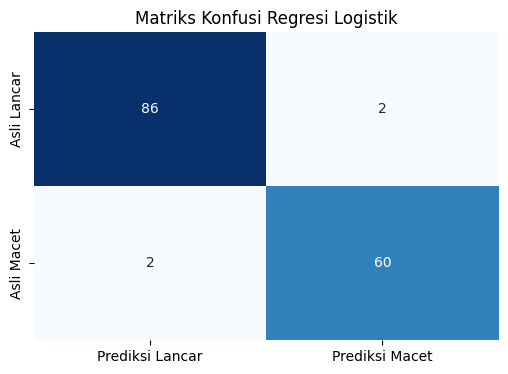


Laporan Evaluasi Klasifikasi Rinci:
              precision    recall  f1-score   support

      Lancar       0.98      0.98      0.98        88
       Macet       0.97      0.97      0.97        62

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



In [5]:
matriks = confusion_matrix(y_test, prediksi_logreg)

plt.figure(figsize=(6, 4))
sns.heatmap(matriks, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Prediksi Lancar', 'Prediksi Macet'],
            yticklabels=['Asli Lancar', 'Asli Macet'])
plt.title('Matriks Konfusi Regresi Logistik')
plt.show()

print("\nLaporan Evaluasi Klasifikasi Rinci:")
print(classification_report(y_test, prediksi_logreg, target_names=['Lancar', 'Macet']))


***
## 5. Kurva ROC dan Area Under Curve (AUC)

### Penjelasan Teori

Model klasifikasi menghitung probabilitas angka desimal terlebih dahulu sebelum menentukan tebakan akhir. Batas tebakan default adalah nol koma lima. Jika kita menurunkan batas probabilitas ini, kita akan mendapatkan lebih banyak tebakan kelas satu, yang meningkatkan Sensitivitas (Recall) tetapi secara bersamaan menurunkan Spesifisitas.

Kurva ROC atau Receiver Operating Characteristic adalah grafik yang memetakan pertukaran nilai sensitivitas melawan nilai positif palsu pada berbagai ambang batas klasifikasi. Area under curve (AUC) menilai seberapa baik pemisahan grafiknya. Skor AUC bernilai satu menunjukkan model yang sempurna.

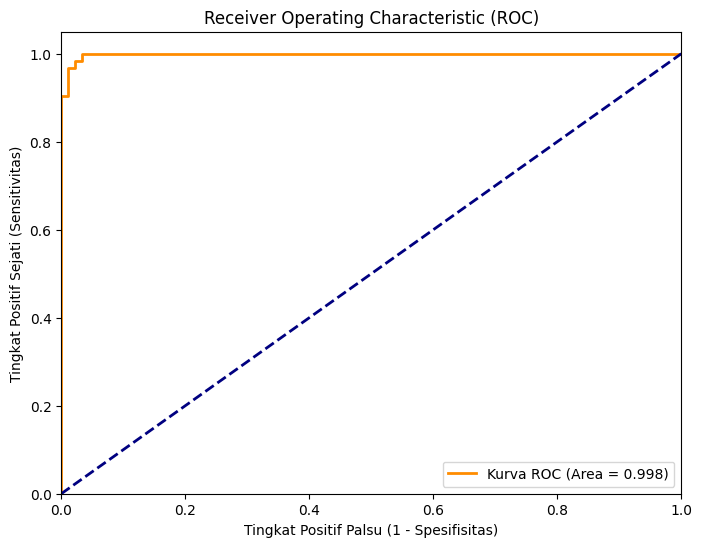

In [6]:
fpr, tpr, thresholds = roc_curve(y_test, probabilitas_logreg)
nilai_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Kurva ROC (Area = {nilai_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='dashed')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tingkat Positif Palsu (1 - Spesifisitas)')
plt.ylabel('Tingkat Positif Sejati (Sensitivitas)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


***
## 6. Strategi Menangani Data Tidak Seimbang (Imbalanced Data)

### Penjelasan Teori

Masalah penipuan transaksi atau deteksi kanker sering kali melibatkan proporsi target yang sangat ekstrim, misalnya satu dari seribu kasus. Model standar akan terjebak menebak kelas mayoritas secara membabi buta hanya untuk mendapatkan persentase akurasi keseluruhan yang tinggi, padahal model menjadi buta sama sekali terhadap kelas yang penting.

Teknik dasar yang diterapkan untuk mencegah bias kelas adalah Oversampling, di mana sampel dari kelas minoritas akan diduplikasi secara acak hingga proporsinya menyamai kelas mayoritas. Kebalikannya adalah Undersampling yang membuang data mayoritas. Pada blok kode di bawah, kita mendemonstrasikan Oversampling secara manual menggunakan fitur indeks acak dari NumPy.

In [7]:
# Simulasi Ekstrim Data Tidak Seimbang (Imbalanced Dataset)
np.random.seed(42)
X_mayoritas = pd.DataFrame(np.random.normal(loc=10, scale=2, size=(950, 2)), columns=['Fitur_1', 'Fitur_2'])
y_mayoritas = pd.Series([0] * 950)

X_minoritas = pd.DataFrame(np.random.normal(loc=15, scale=2, size=(50, 2)), columns=['Fitur_1', 'Fitur_2'])
y_minoritas = pd.Series([1] * 50)

df_imbalanced = pd.concat([X_mayoritas, X_minoritas])
df_imbalanced['Label'] = pd.concat([y_mayoritas, y_minoritas]).values

print("Proporsi Data Sebelum Diperbaiki:")
print(df_imbalanced['Label'].value_counts())

# Eksekusi Oversampling Acak
data_kelas_0 = df_imbalanced[df_imbalanced['Label'] == 0]
data_kelas_1 = df_imbalanced[df_imbalanced['Label'] == 1]

# Menduplikasi kelas minoritas dengan penggantian untuk menyamai jumlah mayoritas
indeks_sampel_baru = np.random.choice(data_kelas_1.index, size=len(data_kelas_0), replace=True)
data_kelas_1_oversampled = df_imbalanced.loc[indeks_sampel_baru]

# Menggabungkan kembali menjadi dataset yang sudah seimbang
df_balanced = pd.concat([data_kelas_0, data_kelas_1_oversampled]).reset_index(drop=True)

print("\nProporsi Data Setelah Melalui Oversampling:")
print(df_balanced['Label'].value_counts())


Proporsi Data Sebelum Diperbaiki:
Label
0    950
1     50
Name: count, dtype: int64

Proporsi Data Setelah Melalui Oversampling:
Label
0    1900
1     950
Name: count, dtype: int64
